In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
arquivo_n = files.upload()
arquivo_c = files.upload()
arquivo_e = files.upload()

Saving normal.jpeg to normal.jpeg


Saving clara.jpeg to clara.jpeg


Saving escura.jpeg to escura.jpeg


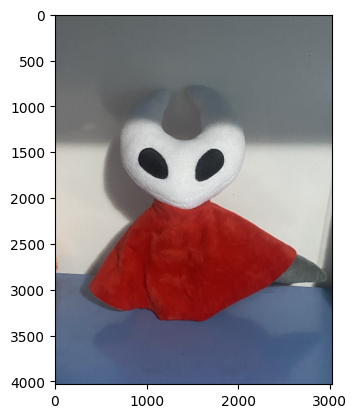

In [5]:
img_rgb_n = cv2.imread('normal.jpeg', cv2.IMREAD_COLOR_RGB)
plt.imshow(img_rgb_n)

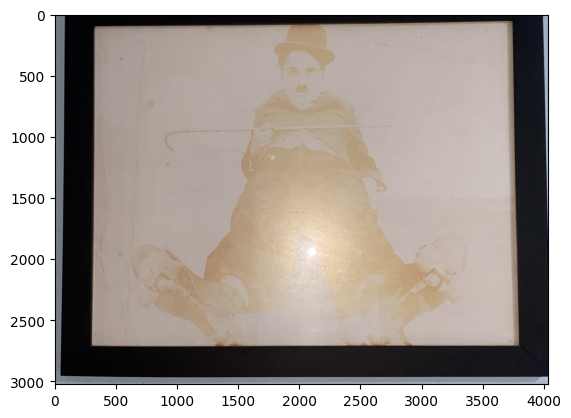

In [6]:
img_rgb_c = cv2.imread('clara.jpeg', cv2.IMREAD_COLOR_RGB)
plt.imshow(img_rgb_c)

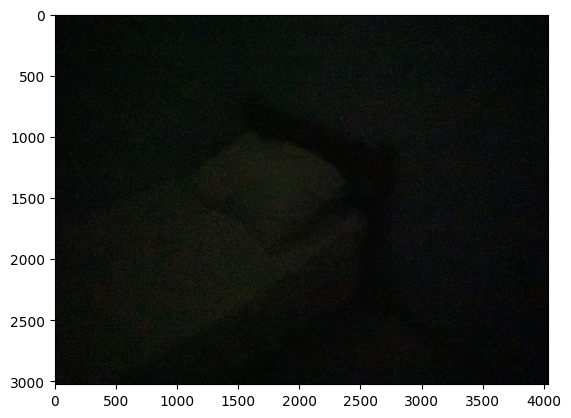

In [7]:
img_rgb_e = cv2.imread('escura.jpeg', cv2.IMREAD_COLOR_RGB)
plt.imshow(img_rgb_e)

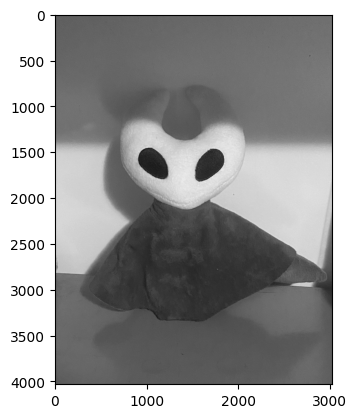

In [17]:
img_gray_n = cv2.cvtColor(img_rgb_n, cv2.COLOR_RGB2GRAY)
plt.imshow(img_gray_n, cmap='gray', vmin=0, vmax=255)

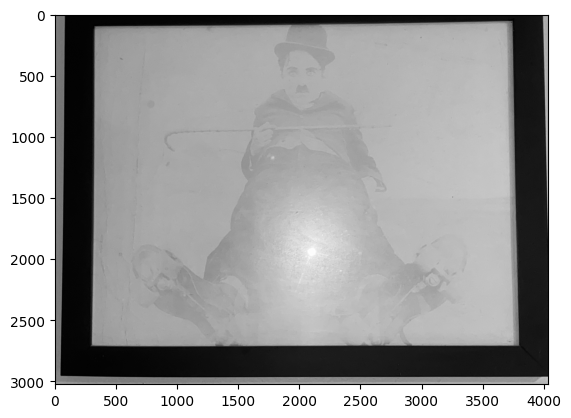

In [20]:
img_gray_c = cv2.cvtColor(img_rgb_c, cv2.COLOR_RGB2GRAY)
plt.imshow(img_gray_c, cmap='gray', vmin=0, vmax=255)

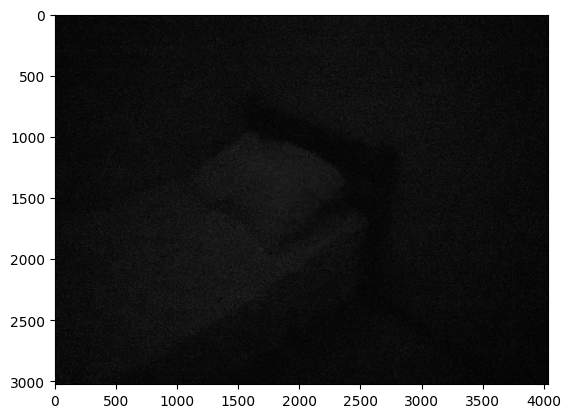

In [15]:
img_gray_e = cv2.cvtColor(img_rgb_e, cv2.COLOR_RGB2GRAY)
plt.imshow(img_gray_e, cmap='gray', vmin=0, vmax=255)

In [21]:
def calcHist(img, titulo):
  hist_arr = np.zeros(256, dtype=int)
  for px in img:
    hist_arr[px] += 1

  plt.bar(range(256), hist_arr)
  plt.title(titulo)

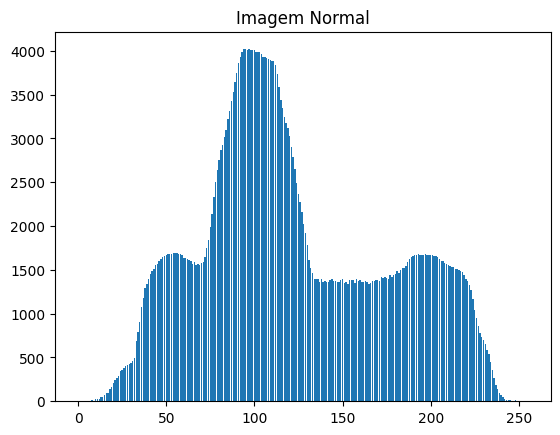

In [22]:
calcHist(img_gray_n, "Imagem Normal")

Na imagem normal, as intensidades estão mais concentradas na faixa de 100 mas ainda tem números consideráveis nas faixas de 50 e 200, o que mostra que os tons são mais neutros ou variados, sem grandes desvios que dificultem a visualização.

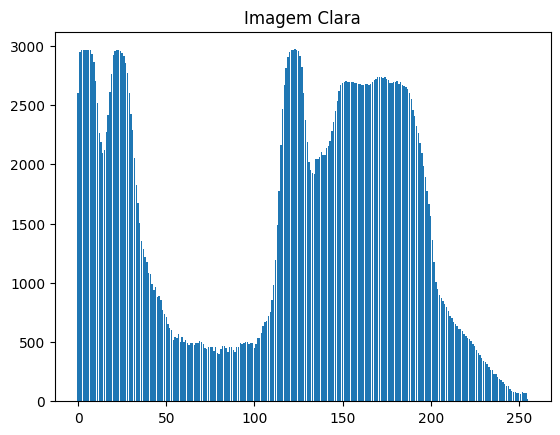

In [23]:
calcHist(img_gray_c, "Imagem Clara")

Na imagem clara, a maioria das intensidades estão concentradas entre 150 e 200, o que indica que a imagem está muito clara. Apesar disso, há um pico de intensidades abaixo de 50 devido à moldura preta do quadro.

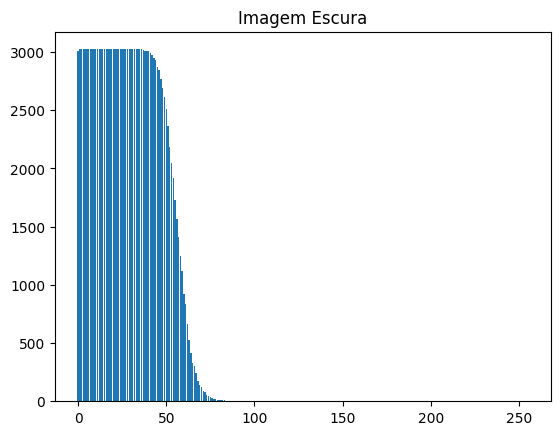

In [24]:
calcHist(img_gray_e, "Imagem Escura")

As intensidades estão concentradas na faixa de 50 para baixo e não há nenhuma intensidade acima de 100, o que demonstra que a imagem está excessivamente escura.

A operação escolhida para modificar as imagens foi correção de gamma, pois as fotos se diferenciam principalmente pela iluminação do ambiente. Foi também testada a expansão de contrastre, mas a imagem normal e a imagem clara têm valores concentrados em múltiplas partes, então não podem ser distribuídos igualmente e continuam praticamente iguais.

In [37]:
def correcao_gamma(img, gamma):
  img_gamma = img/255.0
  resultado = 255*(img_gamma**gamma)
  return resultado.astype(np.uint8)

In [64]:
def plot_gamma(img, gamma, titulo):
  fig, ax = plt.subplots(1, 2, figsize=(6,4))

  ax[0].imshow(img, cmap='gray', vmin=0, vmax=255)
  ax[0].set_title('Original')
  ax[0].axis('off')

  ax[1].imshow(correcao_gamma(img, gamma), cmap='gray', vmin=0, vmax=255)
  ax[1].set_title('Corrigida')
  ax[1].axis('off')

  fig.suptitle(titulo)

  plt.tight_layout()
  plt.show()

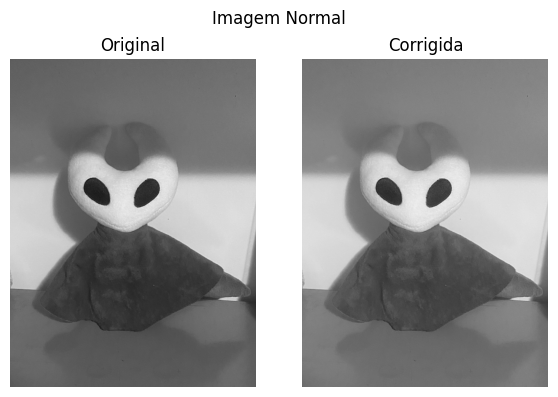

In [87]:
plot_gamma(img_gray_n, 0.8, "Imagem Normal")

Foi escolhido γ = 0.8 a fim de reduzir a intensidade da sombra no topo sem deixar o resto da imagem clara demais.

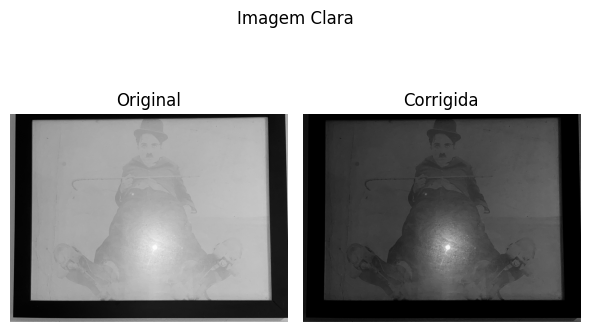

In [66]:
plot_gamma(img_gray_c, 3.5, "Imagem Clara")

Foi escolhido γ = 3.5 para reduzir o brilho da imagem e tornar a foto no quadro mais evidente e não tão escuro.

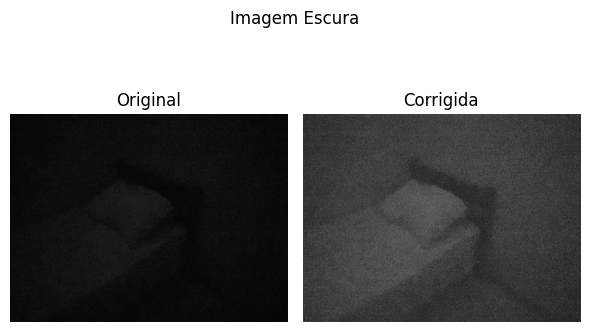

In [79]:
plot_gamma(img_gray_e, 0.45, "Imagem Escura")

Foi escolhido γ = 0.45 para aumentar o brilho e deixar os elementos escuros da imagem mais visíveis sem causar o problema oposto de claridade excessiva.

A operação fez menos diferença na imagem normal, já que o gamma escolhido é próximo a 1. A imagem normal teve este valor de gamma pois já tem intensidades variadas e não é muito clara ou muito escura, então valores mais extremos iriam deixar a imagem com desvio muito grande. Além disso, como a maioria dos tons está concentrado no meio, eles não sofrem mudanças por potenciação quanto os tons mais extremos.